<h2>Load necessary libraries</h2>

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


<h2>Establish the Project Path</h2>

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

print("Project root:")
print(PROJECT_ROOT)

print("\nRaw data:")
print(RAW_DATA_DIR)

Project root:
/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis

Raw data:
/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis/data/raw


<h2>Find the Excel File</h2>

In [4]:
excel_files = list(RAW_DATA_DIR.glob("*.xlsx"))

print("Excel files found:")

for file in excel_files:
    print(file.name)

Excel files found:
online_retail_II.xlsx


In [5]:
DATA_PATH = excel_files[0]

print(DATA_PATH)

/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis/data/raw/online_retail_II.xlsx


<h2>Inspect the Excel Workbook</h2>

In [6]:
excel_file = pd.ExcelFile(DATA_PATH)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Year 2009-2010', 'Year 2010-2011']


<h2>Load the First Year</h2>

In [7]:
df_2009_2010 = pd.read_excel(
    DATA_PATH,
    sheet_name="Year 2009-2010"
)

print("Shape:", df_2009_2010.shape)

df_2009_2010.head()

Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


<h2>Load the Second Year</h2>

In [8]:
df_2010_2011 = pd.read_excel(
    DATA_PATH,
    sheet_name="Year 2010-2011"
)

print("Shape:", df_2010_2011.shape)

df_2010_2011.head()

Shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


<h2>Compare the Two Datasets</h2>

In [9]:
print(
    f"2009-2010 rows: {len(df_2009_2010):,}"
)

print(
    f"2010-2011 rows: {len(df_2010_2011):,}"
)

print(
    f"Total rows: "
    f"{len(df_2009_2010) + len(df_2010_2011):,}"
)

2009-2010 rows: 525,461
2010-2011 rows: 541,910
Total rows: 1,067,371


<h2>Check the Columns</h2>

In [10]:
print("2009-2010 columns:")
print(df_2009_2010.columns.tolist())

print("\n2010-2011 columns:")
print(df_2010_2011.columns.tolist())

2009-2010 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

2010-2011 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


<h2>Combine Both Years</h2>

In [11]:
df = pd.concat(
    [
        df_2009_2010,
        df_2010_2011
    ],
    ignore_index=True
)

In [12]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1067371, 8)


<h2>Preserve the Raw Data</h2>

In [13]:
df_raw = df.copy()

<h2>First Look at the Dataset</h2>

In [14]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,"13,085.00",United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,"13,085.00",United Kingdom


In [15]:
df.tail(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067361,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,"12,680.00",France
1067362,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,"12,680.00",France
1067363,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,"12,680.00",France
1067364,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,"12,680.00",France


In [16]:
df.sample(10, random_state=42)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
455941,532657,21314,SMALL GLASS HEART TRINKET POT,12,2010-11-14 11:10:00,2.10,"14,562.00",United Kingdom
826291,563214,22383,LUNCH BAG SUKI DESIGN,2,2011-08-14 12:56:00,1.65,"16,370.00",United Kingdom
191636,507597,22561,WOODEN SCHOOL COLOURING SET,12,2010-05-10 13:21:00,1.65,"17,700.00",United Kingdom
25864,491634,21588,RETRO SPOT GIANT TUBE MATCHES,1,2009-12-11 15:40:00,2.55,"17,841.00",United Kingdom
73233,496007,85232B,SET/3 RUSSIAN DOLL STACKING TINS,3,2010-01-28 12:32:00,4.95,"15,203.00",United Kingdom
557542,539041,21832,CHOCOLATE CALCULATOR,4,2010-12-15 15:34:00,1.65,"15,456.00",United Kingdom
985772,575905,22089,PAPER BUNTING VINTAGE PAISLEY,6,2011-11-11 15:49:00,2.95,"13,732.00",United Kingdom
568585,540026,21519,GIN & TONIC DIET GREETING CARD,2,2011-01-04 13:25:00,0.85,NaN,United Kingdom
530265,536804,22988,SOLDIERS EGG CUP,72,2010-12-02 16:34:00,1.25,"14,031.00",United Kingdom
649024,546899,20719,WOODLAND CHARLOTTE BAG,50,2011-03-17 18:27:00,0.72,"14,298.00",United Kingdom


<h2>Shape</h2>

In [17]:
rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 1,067,371
Columns: 8


<h2>Data Types</h2>

In [18]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

<h2>info()</h2>

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


<h2>Statistical Summary</h2>
<p>Numeric columns:</p>

In [20]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,"1,067,371.00",1067371,"1,067,371.00","824,364.00"
mean,9.94,2011-01-02 21:13:55.394029,4.65,"15,324.64"
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-07-09 09:46:00,1.25,"13,975.00"
50%,3.00,2010-12-07 15:28:00,2.10,"15,255.00"
75%,10.00,2011-07-22 10:23:00,4.15,"16,797.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,172.71,NaN,123.55,"1,697.46"


<p>Categorical columns:</p>

In [21]:
df.describe(include="object")

,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5305,5698,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


<h2>Missing Values</h2>

In [22]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("Missing %", ascending=False)
)

missing_summary

,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


<h2>Visualize Missingness</h2>

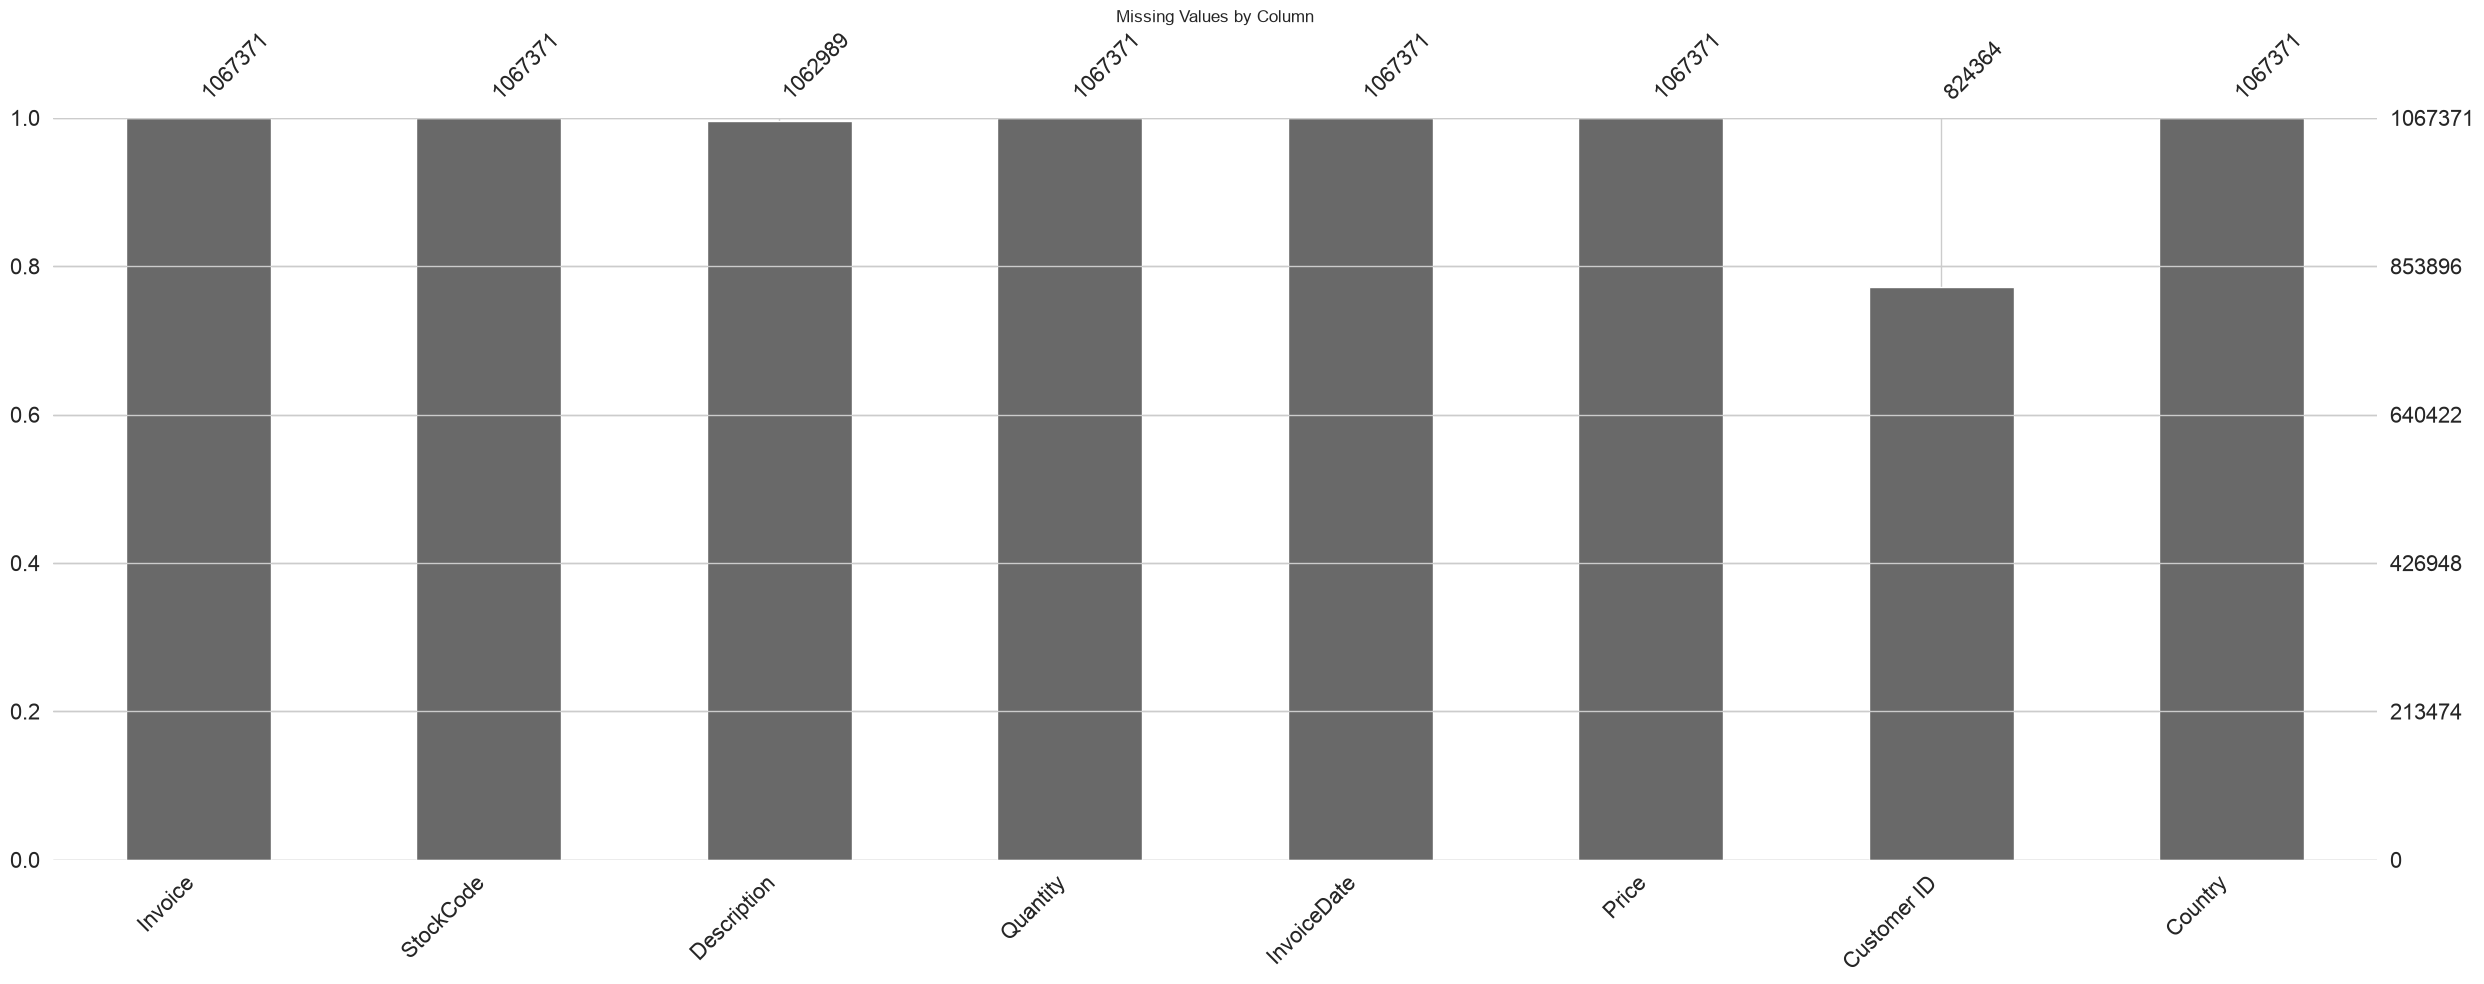

In [23]:
msno.bar(df)

plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

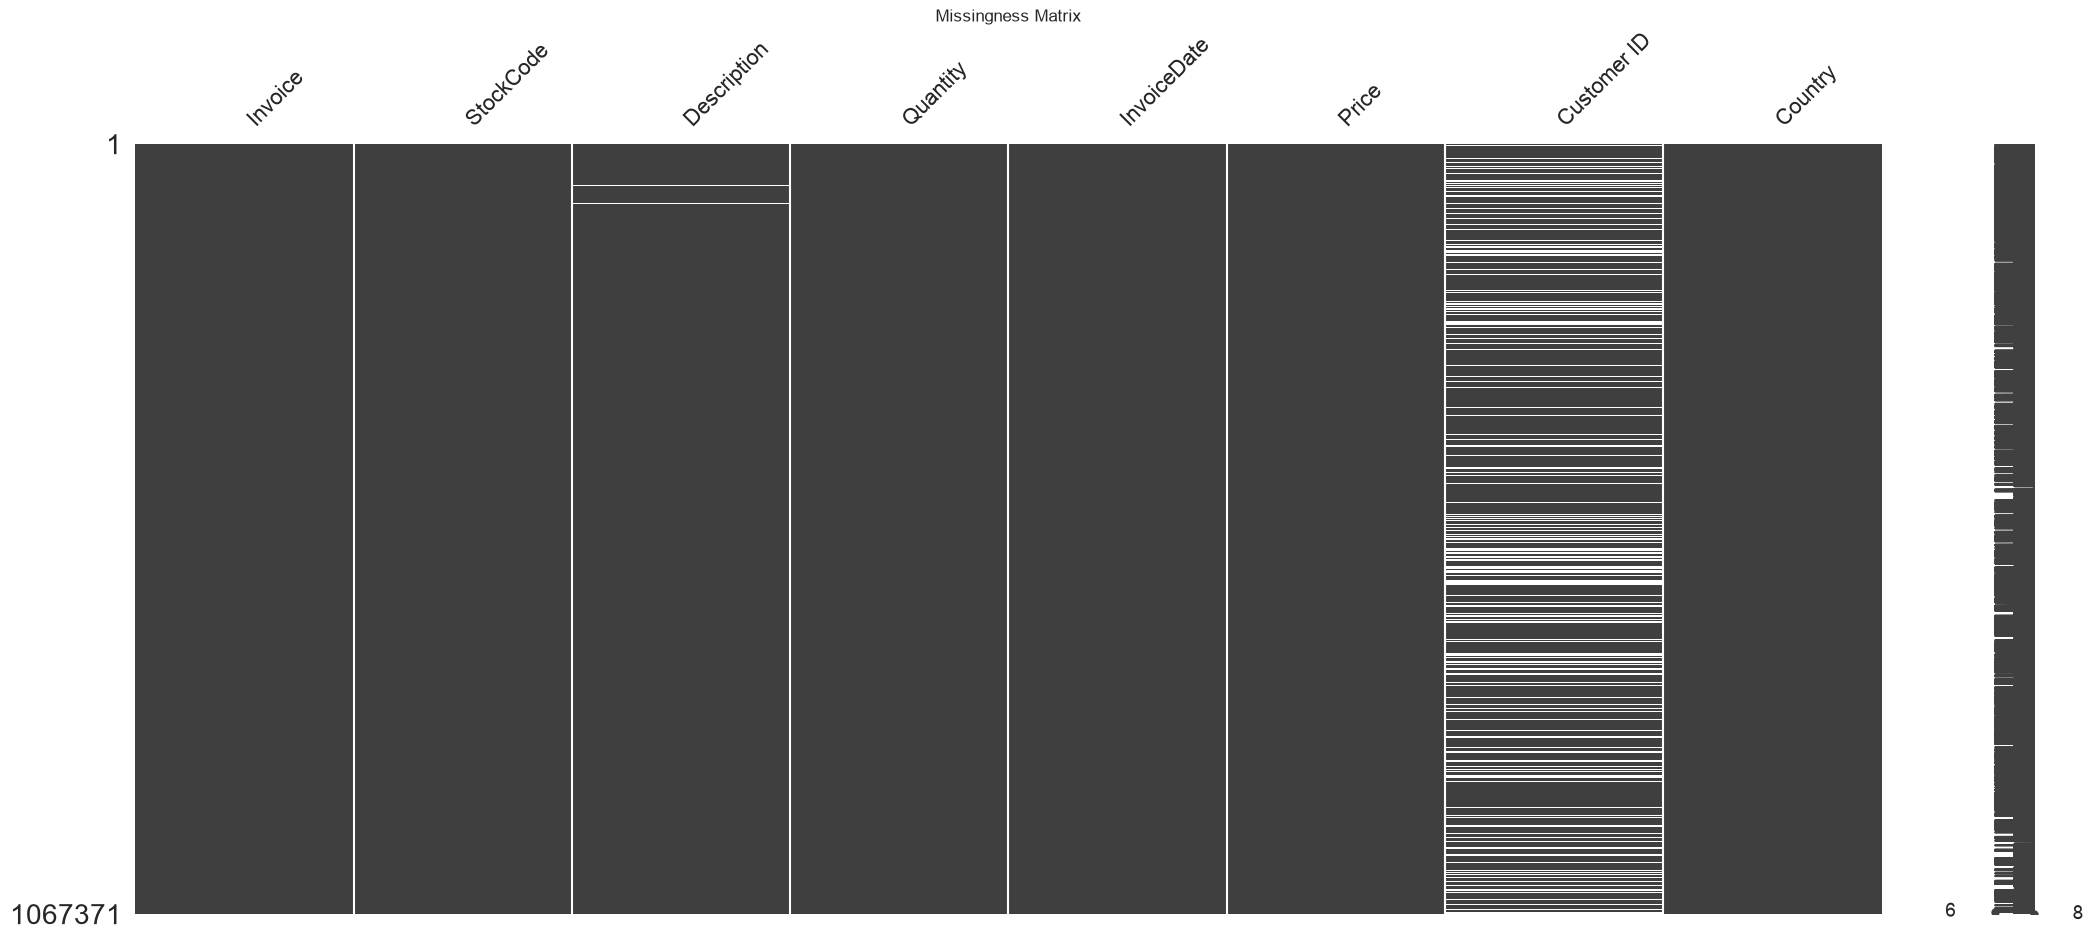

In [24]:
msno.matrix(df)

plt.title("Missingness Matrix")
plt.tight_layout()
plt.show()

<h2>Duplicate Rows</h2>

In [25]:
duplicate_count = df.duplicated().sum()

print(
    f"Exact duplicate rows: "
    f"{duplicate_count:,}"
)

Exact duplicate rows: 34,335


In [26]:
duplicate_percentage = (
    df.duplicated().mean() * 100
)

print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

Duplicate percentage: 3.22%


<h2>Inspect Actual Duplicates</h2>

In [27]:
duplicates = df[
    df.duplicated(keep=False)
].sort_values(
    by=df.columns.tolist()
)

duplicates.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom


<h2>Unique Values</h2>

In [28]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [
        df[column].nunique(dropna=True)
        for column in df.columns
    ],
    "Missing Values": [
        df[column].isna().sum()
        for column in df.columns
    ]
})

unique_summary

,Column,Unique Values,Missing Values
0,Invoice,53628,0
1,StockCode,5305,0
2,Description,5698,4382
3,Quantity,1057,0
4,InvoiceDate,47635,0
5,Price,2807,0
6,Customer ID,5942,243007
7,Country,43,0


<h2>Invoice Analysis</h2>

In [29]:
print(
    f"Unique invoices: "
    f"{df['Invoice'].nunique():,}"
)

Unique invoices: 53,628


In [30]:
invoice_counts = (
    df.groupby("Invoice")
    .size()
    .sort_values(ascending=False)
)

invoice_counts.head(20)

Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
536592    1184
537823    1182
537240    1136
573585    1114
537666    1072
536544    1054
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
580730     662
580367     650
580115     645
dtype: int64

In [31]:
invoice_counts.describe()

count   53,628.00
mean        19.90
std         41.25
min          1.00
25%          2.00
50%          9.00
75%         23.00
max      1,350.00
dtype: float64

<h2>Invoice + Product Combination</h2>

In [33]:
invoice_product_counts = (
    df.groupby(
        ["Invoice", "StockCode"]
    )
    .size()
    .reset_index(
        name="RowCount"
    )
)
invoice_product_counts

,Invoice,StockCode,RowCount
0,489434,21232,1
1,489434,21523,1
2,489434,21871,1
3,489434,22041,1
4,489434,22064,1
...,...,...,...
1021419,C581490,23144,1
1021420,C581499,M,1
1021421,C581568,21258,1
1021422,C581569,20979,1


In [34]:
repeated_invoice_products = (
    invoice_product_counts[
        invoice_product_counts["RowCount"] > 1
    ]
    .sort_values(
        "RowCount",
        ascending=False
    )
)

repeated_invoice_products.head(20)

,Invoice,StockCode,RowCount
686336,555524,22698,20
1014060,C544580,S,16
686335,555524,22697,12
1007918,C514024,M,10
480957,536412,21448,10
490006,537224,70007,10
496034,537646,22585,10
132681,502660,17021,9
488933,537154,22727,8
489481,537202,22147,8


<h2>Negative Quantities</h2>

In [35]:
negative_quantity = df["Quantity"] < 0

print(
    f"Negative quantity rows: "
    f"{negative_quantity.sum():,}"
)

print(
    f"Negative quantity percentage: "
    f"{negative_quantity.mean() * 100:.2f}%"
)

Negative quantity rows: 22,950
Negative quantity percentage: 2.15%


<h2>Zero Quantities</h2>

In [36]:
zero_quantity = df["Quantity"] == 0

print(
    f"Zero quantity rows: "
    f"{zero_quantity.sum():,}"
)

Zero quantity rows: 0


<h2>Price Analysis</h2>

In [37]:
df["Price"].describe()

count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: Price, dtype: float64

In [38]:
zero_price = df["Price"] == 0

print(
    f"Zero-price rows: "
    f"{zero_price.sum():,}"
)

Zero-price rows: 6,202


In [39]:
negative_price = df["Price"] < 0

print(
    f"Negative-price rows: "
    f"{negative_price.sum():,}"
)

Negative-price rows: 5


<h2>Extreme Values</h2>

In [40]:
df["Price"].nlargest(20)

748142    38,970.00
241824    25,111.09
241827    25,111.09
320581    18,910.69
1050063   17,836.46
569163    16,888.02
569164    16,453.71
517953    13,541.33
517955    13,541.33
519294    13,541.33
540477    13,541.33
540478    13,541.33
541817    13,541.33
519170    13,474.79
541463    13,474.79
1050062   11,586.50
825443    11,062.06
135012    10,953.50
135013    10,953.50
135014    10,953.50
Name: Price, dtype: float64

In [41]:
df["Price"].nsmallest(20)

179403   -53,594.36
276274   -44,031.79
403472   -38,925.87
825444   -11,062.06
825445   -11,062.06
263            0.00
283            0.00
284            0.00
470            0.00
3114           0.00
3161           0.00
3162           0.00
3168           0.00
3731           0.00
4296           0.00
4538           0.00
4566           0.00
4674           0.00
5904           0.00
6378           0.00
Name: Price, dtype: float64

In [42]:
df["Quantity"].nlargest(20)

1065882    80995
587080     74215
90857      19152
127166     12960
127168     12960
127169     12744
1027583    12540
127167     12480
192197     10200
135027     10000
135028     10000
135029     10000
135030     10000
296420      9600
93677       9456
432176      9360
65091       9312
298942      7128
326847      7128
358764      7128
Name: Quantity, dtype: int64

In [43]:
df["Quantity"].nsmallest(20)

1065883   -80995
587085    -74215
303996     -9600
750990     -9600
750991     -9600
507225     -9360
529729     -9360
156488     -9200
750989     -9058
194372     -9000
428975     -9000
437008     -8800
359669     -7128
258814     -7100
359670     -7008
269558     -7000
437009     -6400
303995     -6000
641279     -5368
136409     -5200
Name: Quantity, dtype: int64

<h2>Customer IDs</h2>

In [44]:
print(
    f"Unique customers: "
    f"{df['Customer ID'].nunique():,}"
)

Unique customers: 5,942


In [45]:
missing_customer = df["Customer ID"].isna()

print(
    f"Missing Customer IDs: "
    f"{missing_customer.sum():,}"
)

print(
    f"Missing Customer ID %: "
    f"{missing_customer.mean() * 100:.2f}%"
)

Missing Customer IDs: 243,007
Missing Customer ID %: 22.77%


<h2>Countries</h2>

In [46]:
country_counts = (
    df["Country"]
    .value_counts()
)

country_counts.head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

<h2>Products</h2>

In [47]:
print(
    f"Unique products: "
    f"{df['StockCode'].nunique():,}"
)

Unique products: 5,305


In [48]:
df["StockCode"].value_counts().head(20)

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64

<h2>Descriptions</h2>

In [49]:
df["Description"].value_counts().head(30)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
POSTAGE                               2115
WOODEN PICTURE FRAME WHITE FINISH     2115
HEART OF WICKER LARGE                 2112
PACK OF 60 PINK PAISLEY CAKE CASES    2092

<h2>Cancelled Invoices</h2>

In [50]:
cancelled_invoice = (
    df["Invoice"]
    .astype(str)
    .str.startswith("C")
)

print(
    f"Rows associated with cancelled invoices: "
    f"{cancelled_invoice.sum():,}"
)

Rows associated with cancelled invoices: 19,494


In [51]:
df.loc[
    cancelled_invoice,
    "Quantity"
].describe()

count    19,494.00
mean        -25.19
std         805.10
min     -80,995.00
25%          -6.00
50%          -2.00
75%          -1.00
max           1.00
Name: Quantity, dtype: float64

<h3>Raw Transaction Value</h3>

In [52]:
df["RawTotalPrice"] = (
    df["Quantity"] *
    df["Price"]
)

In [53]:
df["RawTotalPrice"].describe()

count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: RawTotalPrice, dtype: float64

In [54]:
print(
    f"Raw transaction value: "
    f"£{df['RawTotalPrice'].sum():,.2f}"
)

Raw transaction value: £19,287,250.57


<h2>Initial Data Quality Report</h2>

In [55]:
data_quality_report = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Exact Duplicate Rows",
        "Missing Customer IDs",
        "Missing Customer ID %",
        "Negative Quantity Rows",
        "Zero Quantity Rows",
        "Zero Price Rows",
        "Negative Price Rows",
        "Cancelled Invoice Rows",
        "Unique Invoices",
        "Unique Customers",
        "Unique Products",
        "Unique Countries"
    ],
    
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["Customer ID"].isna().sum(),
        df["Customer ID"].isna().mean() * 100,
        (df["Quantity"] < 0).sum(),
        (df["Quantity"] == 0).sum(),
        (df["Price"] == 0).sum(),
        (df["Price"] < 0).sum(),
        cancelled_invoice.sum(),
        df["Invoice"].nunique(),
        df["Customer ID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique()
    ]
})

data_quality_report

,Metric,Value
0,Total Rows,"1,067,371.00"
1,Total Columns,9.00
2,Exact Duplicate Rows,"34,335.00"
3,Missing Customer IDs,"243,007.00"
4,Missing Customer ID %,22.77
5,Negative Quantity Rows,"22,950.00"
6,Zero Quantity Rows,0.00
7,Zero Price Rows,"6,202.00"
8,Negative Price Rows,5.00
9,Cancelled Invoice Rows,"19,494.00"


In [56]:
data_quality_report.to_csv(
    REPORTS_DIR / "initial_data_quality_report.csv",
    index=False
)

<h2>Save the Data Dictionary</h2>

In [57]:
data_dictionary = pd.DataFrame({
    "Column": [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ],
    
    "Meaning": [
        "Invoice number identifying a transaction",
        "Product/item identifier",
        "Product description",
        "Number of units purchased",
        "Transaction date and time",
        "Unit price",
        "Customer identifier",
        "Customer country"
    ],
    
    "Current_Dtype": [
        str(df["Invoice"].dtype),
        str(df["StockCode"].dtype),
        str(df["Description"].dtype),
        str(df["Quantity"].dtype),
        str(df["InvoiceDate"].dtype),
        str(df["Price"].dtype),
        str(df["Customer ID"].dtype),
        str(df["Country"].dtype)
    ]
})

data_dictionary

,Column,Meaning,Current_Dtype
0,Invoice,Invoice number identifying a transaction,object
1,StockCode,Product/item identifier,object
2,Description,Product description,object
3,Quantity,Number of units purchased,int64
4,InvoiceDate,Transaction date and time,datetime64[us]
5,Price,Unit price,float64
6,Customer ID,Customer identifier,float64
7,Country,Customer country,str


In [58]:
data_dictionary.to_csv(
    REPORTS_DIR / "data_dictionary.csv",
    index=False
)